In [1]:
import pandas as pd
import numpy as np

### Extract significant BGCs for modules

In [2]:
file_path = '/Users/annasve/Desktop/article_data/output/iterative_WGCNA/analysis/bgc_modules_refined.xlsx'
bgc_modules = pd.read_excel(file_path)

In [3]:
bgc_modules.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_6,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630


In [4]:
file_path = '/Users/annasve/Desktop/article_data/output/iterative_WGCNA/analysis/fishers_001_refined_purity.xlsx'
fishers = pd.read_excel(file_path)

In [5]:
fishers["Strain_Module"] = fishers["Strain"].astype(str) + "_" + fishers["Module"].astype(str)

In [6]:
fishers.head()

,BGC_ID,Module,a_in_bgc_in_module,bgc_size,module_size,strain_genes,odds_ratio,p_value,Strain,BGC_type,FDR,bgc_coverage,module_purity,Strain_Module
0,NBC_01518_34_redox-cofactor,P1_I37_M31,6,11,120,10594,110.200000,8.217137e-10,NBC_01518,refined,3.190506e-08,0.545455,0.050000,NBC_01518_P1_I37_M31
1,NBC_00438_41_other_oligosaccharide,P3_I16_M113,2,3,40,9585,502.315789,5.081095e-05,NBC_00438,refined,8.308139e-04,0.666667,0.050000,NBC_00438_P3_I16_M113
2,NBC_01104_6_NRPS-like_NRPS,P1_I31_M38,8,15,158,7825,58.361905,1.321263e-10,NBC_01104,refined,5.632052e-09,0.533333,0.050633,NBC_01104_P1_I31_M38
3,NBC_00114_11_ectoine,P1_I14_M114,4,4,79,8525,inf,6.832099e-09,NBC_00114,refined,2.348518e-07,1.000000,0.050633,NBC_00114_P1_I14_M114
4,NBC_00805_8_ectoine,P1_I21_M55,4,4,79,6431,inf,2.110169e-08,NBC_00805,refined,6.737526e-07,1.000000,0.050633,NBC_00805_P1_I21_M55


In [7]:
fishers = fishers[["BGC_ID", "Strain_Module"]].rename(columns={"BGC_ID": "relevant_BGC_ID"})

In [8]:
fishers = (
    fishers.groupby("Strain_Module")["relevant_BGC_ID"]
      .apply(lambda s: ",".join(sorted(s.astype(str).unique())))
      .reset_index()
)


In [9]:
bgc_modules = pd.merge(bgc_modules, fishers, how = 'left', on = 'Strain_Module')

In [10]:
bgc_modules.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...


In [11]:
bgc_modules.columns

Index(['Geneid', 'Product', 'Sequence_Length', 'Gene_Kind', 'Is_Core_Gene',
       'Region_Nr', 'corr_to_bgc', 'expressed_any', 'high_corr',
       'refined_member', 'refined_BGC_ID', 'Module', 'kME', 'Cand_Cluster_1',
       'Cluster_Product_1', 'Cand_Cluster_2', 'Cluster_Product_2',
       'Cand_Cluster_3', 'Cluster_Product_3', 'Cand_Cluster_4',
       'Cluster_Product_4', 'prediction', 'score', 'Description',
       'Preferred_name', 'COG_category', 'PFAMs', 'KEGG_Module', 'CAI', 'CBI',
       'Strain', 'Group_ID', 'Locus_ID', 'Overlap_Lengths', 'Strain_Module',
       'motif_id', 'motif_name', 'start', 'site_sequence', 'E_value',
       'significant_site', 'BGC_region', 'BGC_block', '__gorder__',
       'low_expression_rule', 'Region_Nr_original', 'Cand_Cluster_5',
       'Cluster_Product_5', 'Cand_Cluster_6', 'Cluster_Product_6',
       'Cand_Cluster_7', 'Cluster_Product_7', 'Cand_Cluster_8',
       'Cluster_Product_8', 'Cand_Cluster_9', 'Cluster_Product_9',
       'Cand_Cluster_1

In [12]:
bgc_modules_filtered = bgc_modules[bgc_modules["refined_BGC_ID"].isna()]

In [13]:
bgc_modules_filtered.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...


In [14]:
bgc_modules_filtered.to_excel('bgc_module_check.xlsx')

In [15]:
# ---- COG full names (standard) ----
COG_FULLNAME = {
    "A": "RNA processing/modification",
    "B": "Chromatin structure",
    "C": "Energy production",
    "D": "Cell cycle control",
    "E": "Amino acid transport/metabolism",
    "F": "Nucleotide transport/metabolism",
    "G": "Carbohydrate transport/metabolism",
    "H": "Coenzyme transport/metabolism",
    "I": "Lipid transport/metabolism",
    "J": "Translation",
    "K": "Transcription",
    "L": "Replication/recombination/repair",
    "M": "Cell wall biogenesis",
    "N": "Cell motility",
    "O": "Posttranslational modification",
    "P": "Inorganic ion transport/metabolism",
    "Q": "Secondary metabolite biosynthesis",
    "R": "General function prediction only",
    "S": "Function unknown",
    "T": "Signal transduction",
    "U": "Intracellular trafficking",
    "V": "Defense mechanisms",
    "W": "Extracellular structures",
    "Y": "Nuclear structure",
    "Z": "Cytoskeleton",
    "NA": "Unassigned / no COG",
}

# ---- Fixed colors (HEX) for reproducibility ----
# You can change any hex value and it will stay stable forever.
COG_COLOR = {
    "A": "#1f77b4",
    "B": "#aec7e8",
    "C": "#ff7f0e",
    "D": "#ffbb78",
    "E": "#2ca02c",
    "F": "#98df8a",
    "G": "#d62728",
    "H": "#ff9896",
    "I": "#9467bd",
    "J": "#c5b0d5",
    "K": "#8c564b",
    "L": "#c49c94",
    "M": "#e377c2",
    "N": "#f7b6d2",
    "O": "#7f7f7f",
    "P": "#c7c7c7",
    "Q": "#bcbd22",
    "R": "#dbdb8d",
    "S": "#17becf",
    "T": "#9edae5",
    "U": "#393b79",
    "V": "#637939",
    "W": "#8c6d31",
    "Y": "#843c39",
    "Z": "#7b4173",
    "NA": "#000000",
}

# A stable order for legend / consistent appearance
COG_ORDER = [
    "A","B","C","D","E","F","G","H","I","J","K","L",
    "M","N","O","P","Q","R","S","T","U","V","W","Y","Z","NA"
]


In [16]:
import matplotlib.patches as mpatches

def make_cog_legend_handles(cogs_present):
    cogs_present = set(cogs_present)
    handles = []
    for c in COG_ORDER:
        if c in cogs_present:
            label = COG_FULLNAME.get(c, "Unassigned / no COG")
            handles.append(
                mpatches.Patch(
                    color=COG_COLOR.get(c, COG_COLOR["NA"]),
                    label=label
                )
            )
    return handles


In [17]:
PRODUCT_RENAME = {
    "helix-turn-helix domain-containing protein": "HTH domain-containing protein",
    "helix-turn-helix transcriptional regulator": "HTH TR",
    "TetR/AcrR family transcriptional regulator": "TetR TR",
    "GntR family transcriptional regulator": "GntR TR",
    "LysR family transcriptional regulator": "LysR TR",
    "MarR family transcriptional regulator": "MarR TR",
    "MerR family transcriptional regulator": "MerR TR",
    "LacI family transcriptional regulator": "LacI TR",
    "sigma-70 family RNA polymerase sigma factor": "σ70 sigma factor",
    "class I SAM-dependent methyltransferase": "class I SAM methyltransferase",
    "FAD-dependent oxidoreductase": "FAD oxidoreductase",
    "FAD-dependent monooxygenase": "FAD monooxygenase",
    "SDR family oxidoreductase": "SDR oxidoreductase",
    "SDR family NAD(P)-dependent oxidoreductase": "SDR family NAD(P) oxidoreductase",
    "response regulator transcription factor": "response regulator TF",
    "ATP-binding cassette domain-containing protein": "ATP-binding cassette",
    "iron chelate uptake ABC transporter family permease subunit": "iron chelate uptake ABC transporter",
    "LLM class flavin-dependent oxidoreductase": "LLM flavin oxidoreductase",
    "Lrp/AsnC family transcriptional regulator": "Lrp/AsnC TR",
    "ABC transporter ATP-binding protein/permease": "ABC transporter ATP-binding permease",
    "methyltransferase domain-containing protein": "methyltransferase",
    "pyridoxamine 5'-phosphate oxidase family protein": "pyridoxamine 5'-phosphate oxidase",
    "NADP-dependent oxidoreductase": "NADP oxidoreductase",
}


In [18]:

# =========================================================
# SOURCE-OF-TRUTH GENE × BGC TABLE
# =========================================================
# This table keeps one row per gene-BGC link after exploding comma-separated
# relevant_BGC_ID values. It is used for all summaries/enrichment downstream.
# Product-level analyses use product_df, where hypothetical products are removed.
# Orthogroup-level analyses use df / orthogroup_df, where hypothetical products are kept.

import pandas as pd
import numpy as np

df = bgc_modules_filtered.copy()

# Keep only rows linked to at least one BGC
df = df[df["relevant_BGC_ID"].notna()].copy()

# Clean core string columns
for col in ["Product", "Orthogroup", "relevant_BGC_ID"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Split/explode comma-separated BGC IDs
df["relevant_BGC_ID"] = df["relevant_BGC_ID"].str.split(r"\s*,\s*")
df = df.explode("relevant_BGC_ID", ignore_index=True)

df["relevant_BGC_ID"] = df["relevant_BGC_ID"].astype("string").str.strip()
df = df[df["relevant_BGC_ID"].notna() & (df["relevant_BGC_ID"] != "")].copy()

# Extract BGC type from relevant_BGC_ID using the original notebook principle:
# NBC_01734_17_T3PKS -> T3PKS
# NBC_00001_2_NRP-metallophore_NRPS -> NRP-metallophore_NRPS
df["BGC_type"] = (
    df["relevant_BGC_ID"]
    .astype("string")
    .str.split("_", n=3)
    .str[3]
)

df = df[df["BGC_type"].notna()].copy()

def normalize_bgc_type(bgc_type):
    if pd.isna(bgc_type):
        return pd.NA
    parts = str(bgc_type).split("_")
    parts = sorted(parts)
    return "_".join(parts)

df["BGC_type"] = df["BGC_type"].apply(normalize_bgc_type)

# Clean product annotations
df["Product"] = df["Product"].astype("string").str.strip()
bad_products = {"", "-", "nan", "none", "na", "null", "<na>"}
df.loc[
    df["Product"].notna() & df["Product"].str.lower().isin(bad_products),
    "Product"
] = pd.NA

# Product-level analyses exclude hypothetical proteins
hypothetical_mask = df["Product"].astype(str).str.lower().str.contains(
    "hypothetical",
    na=False,
    regex=False
)

product_df = df[
    df["Product"].notna() &
    (~hypothetical_mask)
].copy()

# Orthogroup-level analyses keep hypothetical proteins
orthogroup_df = df.copy()

def bgc_type_counts(series):
    vc = series.dropna().value_counts()
    return "; ".join(f"{k}:{v}" for k, v in vc.items())

def safe_mode(series, default="unknown"):
    s = series.dropna()
    if s.empty:
        return default
    return s.value_counts().idxmax()

def add_cog1(x):
    x = x.copy()
    x["COG1"] = (
        x.get("COG_category", pd.Series([pd.NA] * len(x), index=x.index))
        .astype("string")
        .str.extract(r"([A-Z])", expand=False)
        .fillna("NA")
    )
    return x

df = add_cog1(df)
product_df = add_cog1(product_df)
orthogroup_df = add_cog1(orthogroup_df)

print("Total gene-BGC links:", len(df))
print("Product-level links after removing hypothetical proteins:", len(product_df))
print("Orthogroup-level links keeping hypothetical proteins:", len(orthogroup_df))
print("Unique BGC types:", sorted(df["BGC_type"].dropna().unique())[:20])


Total gene-BGC links: 61647
Product-level links after removing hypothetical proteins: 51637
Orthogroup-level links keeping hypothetical proteins: 61647
Unique BGC types: ['2dos_NRPS-like_T1PKS', '2dos_NRPS_NRPS-like_T1PKS', 'CDPS_NRPS', 'CDPS_NRPS-like_lanthipeptide-class-iv_transAT-PKS', 'CDPS_PKS-like_T1PKS_phenazine', 'CDPS_terpene', 'LAP', 'LAP_NRP-metallophore_NRPS_RRE-containing_thiopeptide', 'LAP_NRPS', 'LAP_NRPS-like_PKS-like_T2PKS_betalactone', 'LAP_NRPS-like_T1PKS_other', 'LAP_NRPS_NRPS-like', 'LAP_NRPS_thiopeptide', 'LAP_RRE-containing_thiopeptide', 'LAP_T2PKS', 'LAP_T2PKS_thiopeptide', 'LAP_blactam_thiopeptide', 'LAP_thiopeptide', 'NI-siderophore', 'NI-siderophore_NRP-metallophore_NRPS']


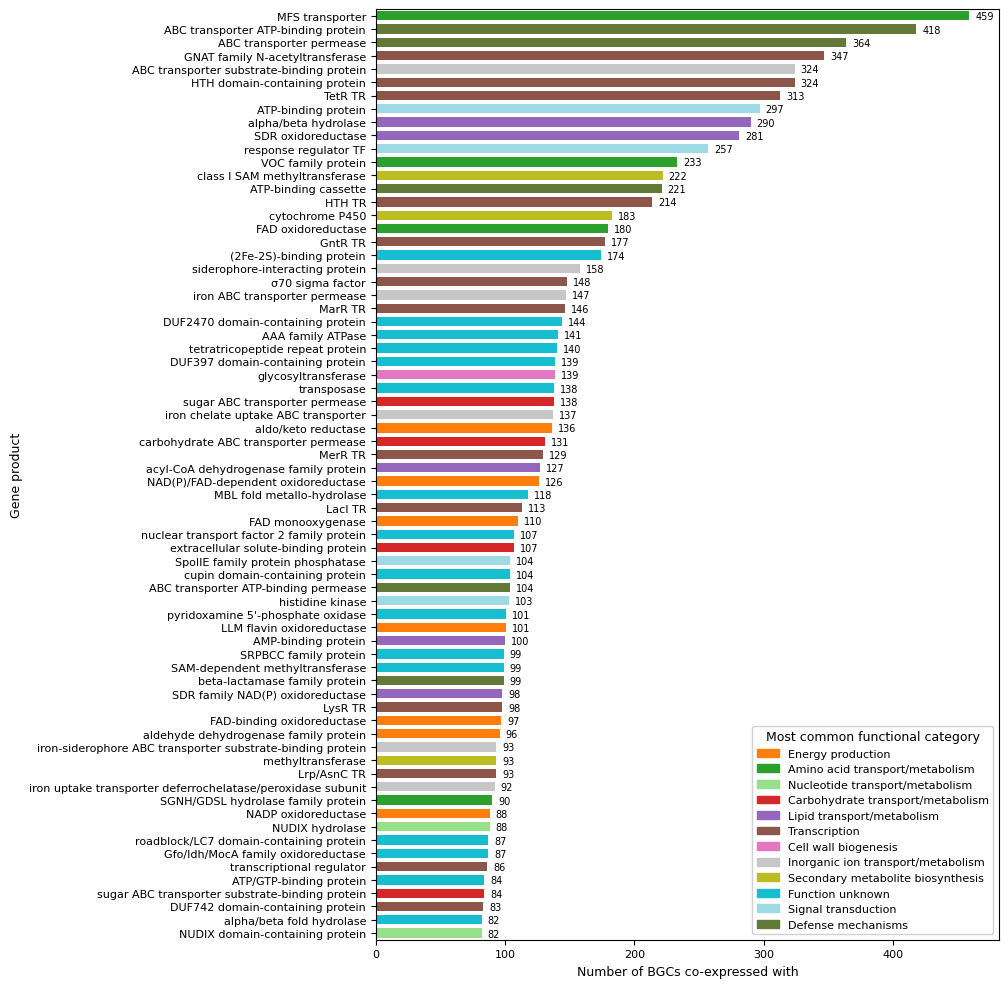

,Product,n_BGCs,top_COG,Product_label
69,NUDIX domain-containing protein,82,F,NUDIX domain-containing protein
68,alpha/beta fold hydrolase,82,S,alpha/beta fold hydrolase
67,DUF742 domain-containing protein,83,K,DUF742 domain-containing protein
66,sugar ABC transporter substrate-binding protein,84,G,sugar ABC transporter substrate-binding protein
65,ATP/GTP-binding protein,84,S,ATP/GTP-binding protein
...,...,...,...,...
4,ABC transporter substrate-binding protein,324,P,ABC transporter substrate-binding protein
3,GNAT family N-acetyltransferase,347,K,GNAT family N-acetyltransferase
2,ABC transporter permease,364,V,ABC transporter permease
1,ABC transporter ATP-binding protein,418,V,ABC transporter ATP-binding protein


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import shorten

TOP_N = 70   # 👈 change this to 30, 40, 50, etc.

df_in = bgc_modules_filtered.copy()

import pandas as pd

# -----------------------------
# 1) Keep only genes linked to ≥1 BGC (and explode if multiple BGCs per cell)
# -----------------------------
d = df_in.copy()

# Keep only rows with a BGC assignment
d = d[d["relevant_BGC_ID"].notna()].copy()

# If relevant_BGC_ID can contain multiple BGCs separated by commas, split+explode
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].astype("string")
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].str.split(r"\s*,\s*")
d = d.explode("relevant_BGC_ID", ignore_index=True)

# Clean up possible empty strings after splitting
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].astype("string").str.strip()
d = d[d["relevant_BGC_ID"].notna() & (d["relevant_BGC_ID"] != "")].copy()

# -----------------------------
# 2) Clean Product and remove bad/hypothetical annotations
# -----------------------------
d["Product"] = d["Product"].astype("string").str.strip()

bad_products = {"", "-", "nan", "none", "na", "null", "<na>"}
d = d[
    d["Product"].notna()
    & (~d["Product"].str.lower().isin(bad_products))
    & (~d["Product"].str.lower().str.contains("hypothetical", na=False, regex=False))
].copy()

# -----------------------------
# 3) Extract single-letter COG category (A–Z), else NA
# -----------------------------
d["COG1"] = (
    d.get("COG_category", pd.Series([pd.NA] * len(d), index=d.index))
     .astype("string")
     .str.extract(r"([A-Z])", expand=False)
     .fillna("NA")
)


# 4) Count DISTINCT BGCs per Product
product_counts = (
    d.groupby("Product")["relevant_BGC_ID"]
     .nunique()
     .reset_index(name="n_BGCs")
     .sort_values("n_BGCs", ascending=False)
)


# 5) Most common COG per Product (still based on genes)
top_cog = (
    d.groupby("Product")["COG1"]
     .agg(lambda s: s.value_counts().idxmax())
     .reset_index(name="top_COG")
)

summary = product_counts.merge(top_cog, on="Product", how="left")
summary["top_COG"] = summary["top_COG"].fillna("NA")


summary = product_counts.merge(top_cog, on="Product", how="left")
summary["top_COG"] = summary["top_COG"].fillna("NA")


# -----------------------------
# 6) Select Top N and plot
# -----------------------------
topN = summary.head(TOP_N).sort_values("n_BGCs", ascending=True).copy()

# Manual renaming (then optional shortening)
topN["Product_label"] = topN["Product"].replace(PRODUCT_RENAME)

# (Optional) shorten anything still too long
# topN["Product_label"] = topN["Product_label"].apply(lambda x: shorten(str(x), width=45, placeholder="…"))

# --- COLORS: use your fixed palette so legend matches bars ---
topN["top_COG"] = topN["top_COG"].fillna("NA")
bar_colors = [COG_COLOR.get(c, COG_COLOR["NA"]) for c in topN["top_COG"]]

# --- Plot ---
# --- Plot ---
fig_h = max(5, 0.14 * TOP_N)      # ↓ smaller per-bar space (less whitespace)
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(
    topN["Product_label"],
    topN["n_BGCs"],
    color=bar_colors,
    height=0.70,                  # ↓ thinner bars but still tight
    edgecolor="none"
)

ax.set_xlabel("Number of BGCs co-expressed with", fontsize=9)
ax.set_ylabel("Gene product", fontsize=9)

ax.margins(y=0.01)
ax.set_ylim(-0.5, len(topN) - 0.5)  # keeps first/last bars aligned (prevents centering weirdness)

# Reduce extra padding above/below the first/last bar
ax.margins(y=0.01)

# --- 1) VALUE LABELS: align to the TOP of the bar (and consistent) ---
# Use bar geometry rather than enumerate (fixes misalignment)
x_offset = max(topN["n_BGCs"]) * 0.01
for b in bars:
    w = b.get_width()
    y_top = b.get_y() + b.get_height() - 0.02  # near top of bar
    ax.text(w + x_offset, y_top, f"{int(w)}", va="top", ha="left", fontsize=7)

# --- 3) LEGEND: only categories present + matching colors ---
present_cogs = list(pd.unique(topN["top_COG"]))
handles = [
    mpatches.Patch(color=COG_COLOR.get(c, COG_COLOR["NA"]), label=COG_FULLNAME.get(c, "Unassigned / no COG"))
    for c in COG_ORDER
    if c in present_cogs
]

ax.legend(
    handles=handles,
    title="Most common functional category",
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title_fontsize=9
)

# Smaller tick labels
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)

plt.tight_layout(pad=0.4)

plt.savefig(
    "Top65_products_BGCs.png",
    dpi=350,
    bbox_inches="tight"
) 

plt.show()

topN


In [20]:
d.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,COG1
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,L
7,OHB55_00250,threonine/serine dehydratase,313.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0005006,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,E
9,OHB55_00320,phage Gp37/Gp68 family protein,251.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008945,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,S


In [21]:
df.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type,COG1
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,L
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S


In [22]:

# -------------------------
# ORTHOGROUP summary
# -------------------------
# Hypothetical proteins are kept for orthogroup-level summaries.

orthogroup_bgc_summary = (
    orthogroup_df[
        orthogroup_df["Orthogroup"].notna()
        & (orthogroup_df["Orthogroup"].astype(str).str.strip() != "Singleton")
    ]
    .groupby("Orthogroup")
    .agg(
        n_genes=("Geneid", "nunique"),
        n_BGCs=("relevant_BGC_ID", "nunique"),
        BGC_IDs=("relevant_BGC_ID", lambda x: ",".join(sorted(set(x.dropna().astype(str))))),
        BGC_types=("BGC_type", lambda x: ",".join(sorted(set(x.dropna().astype(str))))),
        BGC_type_counts=("BGC_type", bgc_type_counts),
    )
    .reset_index()
    .sort_values("n_BGCs", ascending=False)
)

orthogroup_bgc_summary.head()


,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,182,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,221,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:134; NI-siderophore:107;...
238,OG0000238,130,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,162,148,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:11...
1032,OG0001038,117,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...


In [23]:

orthogroup_bgc_summary.head()

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,182,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,221,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:134; NI-siderophore:107;...
238,OG0000238,130,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,162,148,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:11...
1032,OG0001038,117,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...


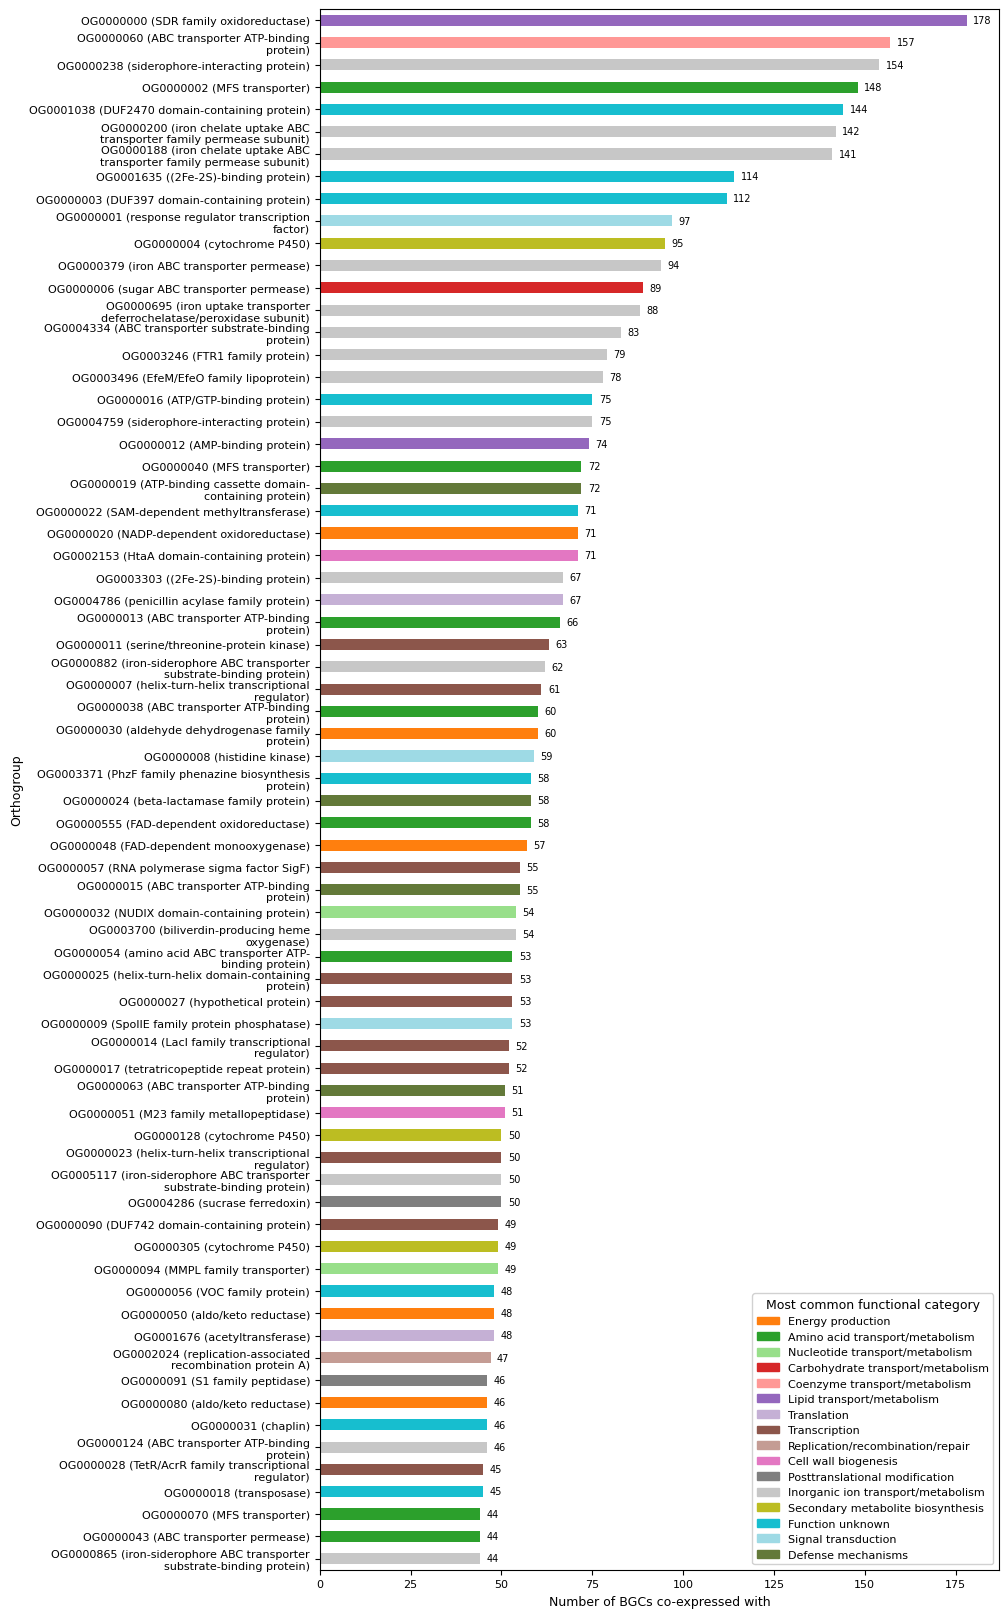

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts,top_COG,top_product,OG_label
69,OG0000865,50,44,"NBC_00101_8_NRP-metallophore_NRPS,NBC_00185_15...","NI-siderophore,NRP-metallophore_NRPS,NRP-metal...",NRP-metallophore_NRPS:40; NI-siderophore:17; N...,P,iron-siderophore ABC transporter substrate-bin...,OG0000865 (iron-siderophore ABC transporter\ns...
68,OG0000043,46,44,"NBC_00216_5_terpene,NBC_00222_30_T1PKS_NRPS_hg...","LAP_NRPS_thiopeptide,NI-siderophore,NRPS,NRPS-...",terpene:8; NRPS_arylpolyene_ladderane:3; T2PKS...,E,ABC transporter permease,OG0000043 (ABC transporter permease)
67,OG0000070,45,44,"NBC_00077_25_NRPS_LAP_NRPS-like,NBC_00101_4_NR...","LAP_NRPS_NRPS-like,LAP_thiopeptide,NI-sideroph...",T2PKS:7; NRPS:4; T1PKS:3; NI-siderophore:3; am...,E,MFS transporter,OG0000070 (MFS transporter)
66,OG0000018,49,45,"NBC_00111_10_NRPS,NBC_00114_29_T2PKS_PKS-like_...","LAP,NI-siderophore,NRP-metallophore_NRPS_NRPS-...",NRPS:5; T2PKS:3; LAP:2; lanthipeptide-class-ii...,S,transposase,OG0000018 (transposase)
65,OG0000028,47,45,"NBC_00012_18_NRPS-like_NRPS,NBC_00024_7_NRP-me...","LAP_blactam_thiopeptide,LAP_thiopeptide,NI-sid...",NRPS:9; LAP_thiopeptide:4; terpene:4; NRP-meta...,K,TetR/AcrR family transcriptional regulator,OG0000028 (TetR/AcrR family transcriptional\nr...
...,...,...,...,...,...,...,...,...,...
4,OG0001038,117,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...,S,DUF2470 domain-containing protein,OG0001038 (DUF2470 domain-containing protein)
3,OG0000002,162,148,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:11...,E,MFS transporter,OG0000002 (MFS transporter)
2,OG0000238,130,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...,P,siderophore-interacting protein,OG0000238 (siderophore-interacting protein)
1,OG0000060,221,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:134; NI-siderophore:107;...,H,ABC transporter ATP-binding protein,OG0000060 (ABC transporter ATP-binding\nprotein)


In [24]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import fill

TOP_N = 70

# --------------------------------------------------
# SOURCE OF TRUTH: use the already computed summary
# --------------------------------------------------
summary = orthogroup_bgc_summary.copy()

# Exclude Singleton here so counts stay otherwise identical
summary = summary[summary["Orthogroup"].astype(str).str.strip() != "Singleton"].copy()

# --------------------------------------------------
# Metadata for label + color
# IMPORTANT: use same Orthogroup-only filter as your summary block
# Hypothetical proteins are kept here.
# --------------------------------------------------
meta = orthogroup_df[orthogroup_df["Orthogroup"].notna()].copy()
meta = meta[meta["Orthogroup"].astype(str).str.strip() != "Singleton"].copy()

meta["Product"] = meta["Product"].astype("string").str.strip()

bad_products = {"", "-", "nan", "none", "na", "null", "<na>"}
meta.loc[
    meta["Product"].notna() & meta["Product"].str.lower().isin(bad_products),
    "Product"
] = pd.NA

meta["COG1"] = (
    meta.get("COG_category", pd.Series([pd.NA] * len(meta), index=meta.index))
        .astype("string")
        .str.extract(r"([A-Z])", expand=False)
        .fillna("NA")
)

def safe_mode(series, default="unknown"):
    s = series.dropna()
    if s.empty:
        return default
    return s.value_counts().idxmax()

og_top_cog = (
    meta.groupby("Orthogroup")["COG1"]
        .apply(lambda s: safe_mode(s, default="NA"))
        .reset_index(name="top_COG")
)

og_top_product = (
    meta.groupby("Orthogroup")["Product"]
        .apply(lambda s: safe_mode(s, default="unknown"))
        .reset_index(name="top_product")
)

summary = (
    summary
    .merge(og_top_cog, on="Orthogroup", how="left")
    .merge(og_top_product, on="Orthogroup", how="left")
)

summary["top_COG"] = summary["top_COG"].fillna("NA")
summary["top_product"] = summary["top_product"].fillna("unknown")

# Store this annotated table for final export
orthogroup_summary_annotated = summary.copy()

# --------------------------------------------------
# Plot top N from the summary itself
# --------------------------------------------------
topN = summary.head(TOP_N).sort_values("n_BGCs", ascending=True).copy()

topN["OG_label"] = (
    topN["Orthogroup"].astype(str)
    + " ("
    + topN["top_product"].astype(str)
    + ")"
).apply(lambda s: fill(s, width=45))

bar_colors = [COG_COLOR.get(c, COG_COLOR["NA"]) for c in topN["top_COG"]]

fig_h = max(7, 0.23 * len(topN))
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(
    topN["OG_label"],
    topN["n_BGCs"],
    color=bar_colors,
    height=0.50,
    edgecolor="none"
)

ax.set_xlabel("Number of BGCs co-expressed with", fontsize=9)
ax.set_ylabel("Orthogroup", fontsize=9)

ax.margins(y=0.03)
ax.set_ylim(-0.5, len(topN) - 0.5)

x_offset = max(topN["n_BGCs"]) * 0.01 if len(topN) > 0 else 0.1
for b in bars:
    w = b.get_width()
    y_top = b.get_y() + b.get_height() - 0.02
    ax.text(w + x_offset, y_top, f"{int(w)}", va="top", ha="left", fontsize=7)

present_cogs = list(pd.unique(topN["top_COG"]))
handles = [
    mpatches.Patch(
        color=COG_COLOR.get(c, COG_COLOR["NA"]),
        label=COG_FULLNAME.get(c, "Unassigned / no COG")
    )
    for c in COG_ORDER
    if c in present_cogs
]

ax.legend(
    handles=handles,
    title="Most common functional category",
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title_fontsize=9
)

ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)

plt.tight_layout(pad=0.4)
plt.savefig("Top70_orthogroups_BGCs_noSingleton.png", dpi=350, bbox_inches="tight")
plt.show()

topN


In [25]:
df[df["Orthogroup"] == "OG0000027"]["Product"].value_counts(dropna=False)

Product
hypothetical protein                    22
transcriptional regulator               20
regulator                               18
MFS transporter                          5
sporulation protein                      5
tetratricopeptide repeat protein         2
transcriptional repressor NsdA           2
XRE family transcriptional regulator     1
DNA-binding protein NsdB                 1
Tat pathway signal protein               1
Name: count, dtype: Int64

In [26]:
# Product_short removed; orthogroup annotations now use Product directly.


In [27]:
bgc_modules_filtered.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...


In [28]:

# df, product_df, and orthogroup_df were prepared above as source-of-truth tables.
# Re-run the preparation cell above if you changed bgc_modules_filtered.
df.head()


,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type,COG1
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,L
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S


In [29]:
df

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type,COG1
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,L
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61642,OIE62_40705,hypothetical protein,468.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0015569,NBC_01770_18_ectoine,ectoine,M
61643,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine,ectoine,Q
61644,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine,ectoine,E
61645,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine,ectoine,M


In [30]:

# BGC_type is already parsed and normalized in the source-of-truth table.
df["BGC_type"].value_counts().head(20)


BGC_type
NI-siderophore              4506
NRPS                        4365
NRP-metallophore_NRPS       3708
terpene                     3449
T2PKS                       2614
T1PKS                       2316
ectoine                     1519
melanin                     1499
RiPP-like                   1188
PKS-like_T1PKS_T2PKS        1129
NRPS_NRPS-like               935
NRPS_T1PKS                   886
NRPS-like                    782
LAP_thiopeptide              722
butyrolactone                679
NRPS_NRPS-like_T1PKS         669
NRPS-like_T1PKS              640
aminopolycarboxylic-acid     584
betalactone                  531
NRPS_T3PKS                   530
Name: count, dtype: int64

In [31]:
df

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type,COG1
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,L
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61642,OIE62_40705,hypothetical protein,468.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0015569,NBC_01770_18_ectoine,ectoine,M
61643,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine,ectoine,Q
61644,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine,ectoine,E
61645,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine,ectoine,M


In [32]:

# Helper retained for compatibility.
def bgc_type_counts(series):
    vc = series.dropna().value_counts()
    return "; ".join(f"{k}:{v}" for k, v in vc.items())


In [33]:

# Product × BGC-type long table
# Product-level analyses exclude hypothetical proteins.
# Count distinct BGCs, not duplicated gene rows.

product_bgc_type_long = (
    product_df.dropna(subset=["Product", "relevant_BGC_ID", "BGC_type"])
      .drop_duplicates(subset=["Product", "relevant_BGC_ID", "BGC_type"])
      .groupby(["Product", "BGC_type"])
      .size()
      .reset_index(name="count")
      .sort_values(["Product", "count"], ascending=[True, False])
)

product_bgc_type_long.head()


,Product,BGC_type,count
0,"(2,3-dihydroxybenzoyl)adenylate synthase",NRP-metallophore_NRPS,1
1,"(2,3-dihydroxybenzoyl)adenylate synthase",NRP-metallophore_NRPS_betalactone,1
4,(2Fe-2S) ferredoxin domain-containing protein,T2PKS_thiopeptide,2
2,(2Fe-2S) ferredoxin domain-containing protein,PKS-like,1
3,(2Fe-2S) ferredoxin domain-containing protein,T1PKS_hglE-KS_lassopeptide,1


In [34]:

# =========================================================
# PRODUCT-LEVEL SUMMARY OF BGC-ASSOCIATED MODULES
# =========================================================
# One row per product annotation.
# Hypothetical proteins are excluded from product-level summaries.
# n_BGCs counts distinct relevant_BGC_ID values from significant BGC-associated modules.

product_bgc_summary = (
    product_df.dropna(subset=["Product", "relevant_BGC_ID"])
      .groupby("Product")
      .agg(
          n_genes=("Geneid", "nunique"),
          n_BGCs=("relevant_BGC_ID", "nunique"),
          top_COG=("COG1", lambda x: safe_mode(x, default="NA")),
          BGC_IDs=("relevant_BGC_ID", lambda x: ",".join(sorted(set(x.dropna().astype(str))))),
          BGC_types=("BGC_type", lambda x: ",".join(sorted(set(x.dropna().astype(str))))),
          BGC_type_counts=("BGC_type", bgc_type_counts),
      )
      .reset_index()
      .sort_values("n_BGCs", ascending=False)
)

product_bgc_summary.head()


,Product,n_genes,n_BGCs,top_COG,BGC_IDs,BGC_types,BGC_type_counts
1399,MFS transporter,778,459,E,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...
217,ABC transporter ATP-binding protein,627,418,V,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...
220,ABC transporter permease,596,364,V,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...
1159,GNAT family N-acetyltransferase,532,347,K,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...
223,ABC transporter substrate-binding protein,406,324,P,"NBC_00001_22_thioamitides,NBC_00001_26_ectoine...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:68; NI-siderophore:63; N...


In [35]:

# Orthogroup × BGC-type long table
# Orthogroup-level analyses keep hypothetical proteins.
# Count distinct BGCs, not duplicated gene rows.

orthogroup_bgc_type_long = (
    orthogroup_df[
        orthogroup_df["Orthogroup"].notna()
        & (orthogroup_df["Orthogroup"].astype(str).str.strip() != "Singleton")
    ]
    .dropna(subset=["Orthogroup", "relevant_BGC_ID", "BGC_type"])
    .drop_duplicates(subset=["Orthogroup", "relevant_BGC_ID", "BGC_type"])
    .groupby(["Orthogroup", "BGC_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["Orthogroup", "count"], ascending=[True, False])
)

orthogroup_bgc_type_long.head()


,Orthogroup,BGC_type,count
5,OG0000000,NI-siderophore,12
14,OG0000000,NRPS,12
10,OG0000000,NRP-metallophore_NRPS,9
64,OG0000000,T2PKS,9
93,OG0000000,terpene,7


In [36]:
orthogroup_bgc_summary

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,182,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,221,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:134; NI-siderophore:107;...
238,OG0000238,130,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,162,148,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:11...
1032,OG0001038,117,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...
...,...,...,...,...,...,...
8173,OG0009817,1,1,NBC_00122_15_terpene,terpene,terpene:1
8174,OG0009818,1,1,NBC_00663_5_NRP-metallophore_NRPS_NRPS-like_T1PKS,NRP-metallophore_NRPS_NRPS-like_T1PKS,NRP-metallophore_NRPS_NRPS-like_T1PKS:1
8175,OG0009821,1,1,NBC_01392_15_lassopeptide_NI-siderophore,NI-siderophore_lassopeptide,NI-siderophore_lassopeptide:1
8179,OG0009827,1,1,NBC_01518_36_NRPS,NRPS,NRPS:1


In [37]:

# Interim export in old-style sheet structure
with pd.ExcelWriter("BGC_coexpression_summaries.xlsx") as writer:
    product_bgc_summary.to_excel(writer, sheet_name="Product_summary", index=False)
    orthogroup_summary_annotated.to_excel(writer, sheet_name="Orthogroup_summary", index=False)
    product_bgc_type_long.to_excel(writer, sheet_name="Product_BGCtype_long", index=False)
    orthogroup_bgc_type_long.to_excel(writer, sheet_name="Orthogroup_BGCtype_long", index=False)


In [38]:
product_bgc_summary.head()

,Product,n_genes,n_BGCs,top_COG,BGC_IDs,BGC_types,BGC_type_counts
1399,MFS transporter,778,459,E,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...
217,ABC transporter ATP-binding protein,627,418,V,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...
220,ABC transporter permease,596,364,V,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...
1159,GNAT family N-acetyltransferase,532,347,K,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...
223,ABC transporter substrate-binding protein,406,324,P,"NBC_00001_22_thioamitides,NBC_00001_26_ectoine...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:68; NI-siderophore:63; N...


### Fishers test for significantly enriched BGC_types (product)

In [39]:

bgc_df = bgc_modules.copy()

# keep only real BGCs
bgc_df = bgc_df[
    bgc_df["refined_BGC_ID"].notna() &
    bgc_df["Strain"].notna()
].copy()

# normalize BGC types to match BGC_type parsed from relevant_BGC_ID
bgc_df["BGC_type_norm"] = (
    bgc_df["Cluster_Product_1"]
    .astype("string")
    .str.replace(", ", "_", regex=False)
    .str.replace(",", "_", regex=False)
    .apply(normalize_bgc_type)
)

# one row = one distinct BGC
bgc_universe = (
    bgc_df[["Strain", "refined_BGC_ID", "BGC_type_norm"]]
    .drop_duplicates()
)

total_bgcs = bgc_universe.shape[0]

bgc_type_totals = (
    bgc_universe
    .dropna(subset=["BGC_type_norm"])
    ["BGC_type_norm"]
    .value_counts()
)


In [40]:
bgc_type_totals

BGC_type_norm
terpene                           209
NI-siderophore                    142
NRPS                              106
T1PKS                              75
NRP-metallophore_NRPS              70
                                 ... 
betalactone_terpene                 1
T1PKS_betalactone_phenazine         1
T1PKS_ladderane_other               1
NAPAA_NRPS_T1PKS_melanin            1
NRPS_butyrolactone_prodigiosin      1
Name: count, Length: 358, dtype: int64

In [41]:
total_bgcs_across_types = bgc_type_totals.sum()
total_bgcs_across_types


2061

In [42]:
import pandas as pd
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

In [43]:
df = product_bgc_type_long.copy()

# Totals
total_bgcs = df["count"].sum()
product_totals = df.groupby("Product")["count"].sum()
type_totals = df.groupby("BGC_type")["count"].sum()

In [44]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

rows = []

for _, r in df.iterrows():
    product = r["Product"]
    bgc_type = r["BGC_type"]
    a = r["count"]   # BGCs with this Product AND this BGC type

    # Skip unstable cases
    if a < 1:
        continue
    if product not in product_totals:
        continue
    if bgc_type not in bgc_type_totals:
        continue

    # --- CONTINGENCY TABLE ---
    # a = product ∩ bgc_type
    b = product_totals[product] - a          # product & other BGC types
    c = bgc_type_totals[bgc_type] - a        # bgc_type & other products
    d = total_bgcs - a - b - c               # neither

    # Guard against invalid tables
    if min(a, b, c, d) < 0:
        continue

    odds_ratio, pval = fisher_exact(
        [[a, b],
         [c, d]],
        alternative="greater"
    )

    rows.append({
        "Product": product,
        "BGC_type": bgc_type,
        "count": a,
        "product_total": product_totals[product],
        "bgc_type_total": bgc_type_totals[bgc_type],
        "odds_ratio": odds_ratio,
        "p_value": pval
    })

results_df = pd.DataFrame(rows)

# -----------------------------
# Multiple testing correction
# -----------------------------
if not results_df.empty:
    results_df["FDR"] = smm.multipletests(
        results_df["p_value"],
        method="fdr_bh"
    )[1]

    results_df = results_df.sort_values(
        ["FDR", "odds_ratio"],
        ascending=[True, False]
    ).reset_index(drop=True)


In [45]:
results_df.head()

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,63,158,142,369.328581,5.004364e-120,1.611656e-115
1,DUF2470 domain-containing protein,NI-siderophore,58,144,142,353.315061,2.463242e-110,3.966435e-106
2,DUF2470 domain-containing protein,NRP-metallophore_NRPS,49,144,70,1082.396491,4.639035e-109,4.980004e-105
3,siderophore-interacting protein,NRP-metallophore_NRPS,49,158,70,943.073394,1.100997e-106,8.864405e-103
4,iron chelate uptake ABC transporter family per...,NRP-metallophore_NRPS,44,137,70,801.953681,1.810417e-95,1.166089e-91


In [46]:
filtered_results = results_df[
    (results_df["FDR"] < 0.01) &
    (results_df["count"] >= 5) &
    (results_df["count"] / results_df["bgc_type_total"] >= 0.10)
].copy()


In [47]:
filtered_results.head()

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,63,158,142,369.328581,5.004364e-120,1.611656e-115
1,DUF2470 domain-containing protein,NI-siderophore,58,144,142,353.315061,2.463242e-110,3.966435e-106
2,DUF2470 domain-containing protein,NRP-metallophore_NRPS,49,144,70,1082.396491,4.639035e-109,4.980004e-105
3,siderophore-interacting protein,NRP-metallophore_NRPS,49,158,70,943.073394,1.100997e-106,8.864405e-103
4,iron chelate uptake ABC transporter family per...,NRP-metallophore_NRPS,44,137,70,801.953681,1.810417e-95,1.166089e-91


In [48]:
filtered_results.to_excel('BGC_type_gene_enrichment_product.xlsx')

In [49]:
# bgc_type_totals: index = BGC_type, value = number of distinct BGCs
major_types = (
    bgc_type_totals
    .sort_values(ascending=False)
    .head(8)   # ← 5–7 is ideal for a figure
    .index
    .tolist()
)


In [50]:
major_types

['terpene',
 'NI-siderophore',
 'NRPS',
 'T1PKS',
 'NRP-metallophore_NRPS',
 'ectoine',
 'RiPP-like',
 'T2PKS']

In [51]:
filtered_major = filtered_results[
    filtered_results["BGC_type"].isin(major_types)
].copy()


In [52]:
filtered_major

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,63,158,142,369.328581,5.004364e-120,1.611656e-115
1,DUF2470 domain-containing protein,NI-siderophore,58,144,142,353.315061,2.463242e-110,3.966435e-106
2,DUF2470 domain-containing protein,NRP-metallophore_NRPS,49,144,70,1082.396491,4.639035e-109,4.980004e-105
3,siderophore-interacting protein,NRP-metallophore_NRPS,49,158,70,943.073394,1.100997e-106,8.864405e-103
4,iron chelate uptake ABC transporter family per...,NRP-metallophore_NRPS,44,137,70,801.953681,1.810417e-95,1.166089e-91
...,...,...,...,...,...,...,...,...
1293,SDR family oxidoreductase,RiPP-like,6,281,54,19.956818,1.245770e-06,3.101774e-05
1390,ABC transporter substrate-binding protein,T2PKS,6,324,50,18.810463,1.786308e-06,4.135733e-05
1410,FAD-dependent oxidoreductase,T2PKS,5,180,50,27.942222,1.927496e-06,4.399364e-05
1745,class I SAM-dependent methyltransferase,T2PKS,5,222,50,22.512545,5.365069e-06,9.895878e-05


In [53]:
# Select the top 10 product enrichments per BGC type by statistical significance (FDR).
# The heatmaps still plot enrichment strength as log10(odds_ratio).
top_per_type = (
    filtered_major
    .sort_values(["BGC_type", "FDR", "odds_ratio"], ascending=[True, True, False])
    .groupby("BGC_type", group_keys=False)
    .head(10)
)


In [54]:
heatmap_df = (
    top_per_type
    .assign(logOR=lambda x: np.log10(x["odds_ratio"]))
    .pivot_table(
        index="Product",
        columns="BGC_type",
        values="logOR",
        aggfunc="max"
    )
    .clip(upper=4)
)


In [55]:
top_per_type

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,63,158,142,369.328581,5.004364e-120,1.611656e-115
1,DUF2470 domain-containing protein,NI-siderophore,58,144,142,353.315061,2.463242e-110,3.966435e-106
6,(2Fe-2S)-binding protein,NI-siderophore,53,174,142,216.404773,1.465692e-92,6.743228e-89
7,iron chelate uptake ABC transporter family per...,NI-siderophore,50,137,142,274.893803,7.515977e-92,3.025651e-88
10,iron ABC transporter permease,NI-siderophore,47,147,142,217.644632,6.912850e-83,2.023894e-79
...,...,...,...,...,...,...,...,...
57,helix-turn-helix domain-containing protein,terpene,26,324,209,20.847581,3.432153e-24,1.905732e-21
70,MFS transporter,terpene,27,459,209,14.970124,1.563003e-21,7.089648e-19
73,class I SAM-dependent methyltransferase,terpene,21,222,209,24.354398,3.150374e-21,1.371051e-18
82,alpha/beta hydrolase,terpene,22,290,209,19.208516,4.324543e-20,1.677975e-17


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from textwrap import wrap

# -----------------------------
# PREP
# -----------------------------
df_plot = top_per_type.copy()

df_plot["logOR"] = np.log10(df_plot["odds_ratio"].astype(float))
CAP = 4.0
df_plot["logOR"] = df_plot["logOR"].clip(upper=CAP)

bgc_types = [
    "terpene", "NI-siderophore", "NRPS", "T1PKS",
    "NRP-metallophore_NRPS", "ectoine", "RiPP-like", "T2PKS"
]
df_plot = df_plot[df_plot["BGC_type"].isin(bgc_types)].copy()

# optional ordering
type_strength = (
    df_plot.groupby("BGC_type")["logOR"]
    .quantile(0.90)
    .sort_values(ascending=False)
)
bgc_types = type_strength.index.tolist()

# -----------------------------
# Label formatter: FULL TEXT, allow up to 3 lines, NO truncation
# -----------------------------
def format_product_label_full(prod, count=None, width=26, max_lines=3):
    s = str(prod)
    if "PRODUCT_RENAME" in globals():
        s = PRODUCT_RENAME.get(s, s)

    if count is not None and pd.notna(count):
        s = f"{s} ({int(count)})"

    lines = wrap(s, width=width)

    # NO truncation: keep full text, just wrap
    if max_lines is None:
        return "\n".join(lines)

    # If you truly want "even if it has to be 3 lines", keep at most 3 lines,
    # but DO NOT cut content -> we increase wrap width if it would exceed max_lines.
    # This preserves full text without truncation by making lines longer.
    if len(lines) <= max_lines:
        return "\n".join(lines)

    # Increase width until it fits in max_lines (still full text)
    w = width
    while True:
        w += 2
        lines2 = wrap(s, width=w)
        if len(lines2) <= max_lines or w >= 120:
            return "\n".join(lines2)

# global scale (recommended for comparability across types)
vmin = 0
vmax = float(df_plot["logOR"].max())
norm = Normalize(vmin=vmin, vmax=vmax)

# -----------------------------
# FUNCTION: plot ONE BGC type
# -----------------------------
def plot_one_type(
    df_plot: pd.DataFrame,
    bgc_type: str,
    vmin: float,
    vmax: float,
    cmap: str = "icefire",
    label_wrap_width: int = 26,
    label_max_lines: int = 3,   # <-- 3 lines allowed
    figsize=(6.2, 6.2),         # <-- taller to accommodate 3-line labels
    dpi=300,
    savepath: str | None = None
):
    sub = df_plot[df_plot["BGC_type"] == bgc_type].copy().sort_values("logOR", ascending=False)

    # build labels (FULL text, no truncation)
    if "count" in sub.columns:
        sub["Product_label"] = [
            format_product_label_full(p, cnt, width=label_wrap_width, max_lines=label_max_lines)
            for p, cnt in zip(sub["Product"], sub["count"])
        ]
    else:
        sub["Product_label"] = [
            format_product_label_full(p, None, width=label_wrap_width, max_lines=label_max_lines)
            for p in sub["Product"]
        ]

    mat = sub.set_index("Product_label")[["logOR"]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        linewidths=0.3,
        linecolor="lightgray",
        cbar_kws={"label": "log10(Odds ratio)"}
    )

    ax.set_title(bgc_type, fontsize=12, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(["log10(OR)"], rotation=0, fontsize=9)

    # y labels: a bit smaller helps 3-line labels
    ax.tick_params(axis="y", labelsize=10, pad=2)

    for lab in ax.get_yticklabels():
        lab.set_horizontalalignment("right")

    # make sure nothing is clipped
    plt.tight_layout(pad=0.8)

    if savepath:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.05, dpi = 350)
        plt.close(fig)
    else:
        plt.show()

# -----------------------------
# LOOP: generate & save all panels
# -----------------------------
for t in bgc_types:
    safe = t.replace("/", "_").replace(" ", "_")
    plot_one_type(
        df_plot=df_plot,
        bgc_type=t,
        vmin=vmin,
        vmax=vmax,
        figsize=(6.2, 6.2),  # increase height if you still have many rows
        savepath=f"{safe}_heatmap.png"
    )


### Fishers test for significantly enriched BGC_types (orthogroup)

In [57]:

# Orthogroup enrichment source table
# Orthogroup-level enrichment keeps hypothetical proteins.

df_og_enrich = (
    orthogroup_df[
        orthogroup_df["Orthogroup"].notna()
        & (orthogroup_df["Orthogroup"].astype(str).str.strip() != "Singleton")
    ]
    .dropna(subset=["Orthogroup", "Product", "relevant_BGC_ID", "BGC_type"])
    .copy()
)

df_unique = (
    df_og_enrich[["Orthogroup", "Product", "relevant_BGC_ID", "BGC_type"]]
    .drop_duplicates()
    .rename(columns={"relevant_BGC_ID": "BGC_ID"})
)

df_unique.head()


,Orthogroup,Product,BGC_ID,BGC_type
1,OG0002919,DUF5667 domain-containing protein,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
2,OG0003840,GNAT family N-acetyltransferase,NBC_01734_17_T3PKS,T3PKS
3,OG0000851,NUDIX hydrolase,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
4,OG0008630,hypothetical protein,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
7,OG0005006,threonine/serine dehydratase,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS


In [58]:
df_unique.head()


,Orthogroup,Product,BGC_ID,BGC_type
1,OG0002919,DUF5667 domain-containing protein,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
2,OG0003840,GNAT family N-acetyltransferase,NBC_01734_17_T3PKS,T3PKS
3,OG0000851,NUDIX hydrolase,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
4,OG0008630,hypothetical protein,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
7,OG0005006,threonine/serine dehydratase,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS


In [59]:
orthogroup_bgc_type_long = (
    df_unique
    .groupby(["Orthogroup", "BGC_type"])
    .size()
    .reset_index(name="count")
)


In [60]:
orthogroup_totals = (
    df_unique
    .groupby("Orthogroup")["BGC_ID"]
    .nunique()
)


In [61]:
def safe_mode(series, default="unknown"):
    s = series.dropna()
    if s.empty:
        return default
    return s.value_counts().idxmax()

orthogroup_top_product = (
    df_unique
    .groupby("Orthogroup")["Product"]
    .apply(lambda s: safe_mode(s, default="unknown"))
)


In [62]:

# Use the same BGC universe and normalized BGC types as product enrichment
bgc_type_totals = (
    bgc_universe
    .dropna(subset=["BGC_type_norm"])
    ["BGC_type_norm"]
    .value_counts()
)


In [63]:

total_bgcs = bgc_universe.drop_duplicates(subset=["Strain", "refined_BGC_ID"]).shape[0]


In [64]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

rows = []

for _, r in orthogroup_bgc_type_long.iterrows():
    og = r["Orthogroup"]
    bgc_type = r["BGC_type"]
    a = r["count"]

    if a < 1:
        continue

    og_total = orthogroup_totals.get(og, 0)
    type_total = bgc_type_totals.get(bgc_type, 0)

    b = og_total - a
    c = type_total - a
    d = total_bgcs - a - b - c

    if min(a, b, c, d) < 0:
        continue

    odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")

    rows.append({
        "Orthogroup": og,
        "BGC_type": bgc_type,
        "count": a,
        "orthogroup_total": og_total,
        "bgc_type_total": type_total,
        "most_common_product": orthogroup_top_product.get(og, "unknown"),
        "odds_ratio": odds_ratio,
        "p_value": pval
    })

results_og = pd.DataFrame(rows)


In [65]:
results_og["FDR"] = smm.multipletests(
    results_og["p_value"],
    method="fdr_bh"
)[1]

results_og = results_og.sort_values(
    ["FDR", "odds_ratio"],
    ascending=[True, False]
).reset_index(drop=True)


In [66]:
results_og.head()

,Orthogroup,BGC_type,count,orthogroup_total,bgc_type_total,most_common_product,odds_ratio,p_value,FDR
0,OG0000188,NRP-metallophore_NRPS,64,141,70,iron chelate uptake ABC transporter family per...,268.329004,1.410156e-74,6.823461e-70
1,OG0000060,NI-siderophore,78,157,142,ABC transporter ATP-binding protein,28.740902,1.073099e-57,2.596257e-53
2,OG0000200,NRP-metallophore_NRPS,50,142,70,iron chelate uptake ABC transporter family per...,52.228261,2.895644e-46,4.670481e-42
3,OG0001038,NRP-metallophore_NRPS,49,144,70,DUF2470 domain-containing protein,47.133333,3.221511e-44,3.897062e-40
4,OG0000188,NI-siderophore,65,141,142,iron chelate uptake ABC transporter family per...,20.726247,5.993099e-44,5.799881e-40


In [67]:
filtered_results_og = results_og[
    (results_og["FDR"] < 0.01) &
    (results_og["count"] >= 5) &
    (results_og["count"] / results_og["bgc_type_total"] >= 0.10)
].copy()


In [68]:
filtered_results_og.to_excel('orthogroup_bgc_type_summary.xlsx')

In [69]:
filtered_major_og = filtered_results_og[
    filtered_results_og["BGC_type"].isin(major_types)
].copy()


In [70]:
# Select the top 10 orthogroup enrichments per BGC type by statistical significance (FDR).
# The heatmaps still plot enrichment strength as log10(odds_ratio).
top_per_type_og = (
    filtered_major_og
    .sort_values(["BGC_type", "FDR", "odds_ratio"], ascending=[True, True, False])
    .groupby("BGC_type", group_keys=False)
    .head(10)
)


In [71]:
top_per_type_og

,Orthogroup,BGC_type,count,orthogroup_total,bgc_type_total,most_common_product,odds_ratio,p_value,FDR
1,OG0000060,NI-siderophore,78,157,142,ABC transporter ATP-binding protein,28.740902,1.073099e-57,2.596257e-53
4,OG0000188,NI-siderophore,65,141,142,iron chelate uptake ABC transporter family per...,20.726247,5.993099e-44,5.799881e-40
6,OG0000200,NI-siderophore,59,142,142,iron chelate uptake ABC transporter family per...,15.921179,3.621622e-36,2.503472e-32
8,OG0000238,NI-siderophore,60,154,142,siderophore-interacting protein,14.385054,6.713078e-35,3.609249e-31
9,OG0001038,NI-siderophore,58,144,142,DUF2470 domain-containing protein,14.901440,1.458076e-34,7.055337e-31
14,OG0004786,NI-siderophore,37,67,142,penicillin acylase family protein,22.458413,1.160535e-27,3.743731e-24
18,OG0001635,NI-siderophore,42,114,142,(2Fe-2S)-binding protein,10.908333,1.445716e-22,3.681859e-19
19,OG0003246,NI-siderophore,35,79,142,FTR1 family protein,14.110025,6.497900e-22,1.572102e-18
20,OG0003303,NI-siderophore,32,67,142,(2Fe-2S)-binding protein,15.850390,2.747811e-21,6.331480e-18
21,OG0000695,NI-siderophore,35,88,142,iron uptake transporter deferrochelatase/perox...,11.658438,5.188718e-20,1.141235e-16


In [72]:
heatmap_df_og = (
    top_per_type_og
    .assign(logOR=lambda x: np.log10(x["odds_ratio"]))
    .pivot_table(
        index="Orthogroup",
        columns="BGC_type",
        values="logOR",
        aggfunc="max"
    )
    .clip(upper=4)
)


In [73]:
heatmap_df_og

BGC_type,NI-siderophore,NRP-metallophore_NRPS,T2PKS
Orthogroup,,,
OG0000060,1.458500,NaN,NaN
OG0000096,NaN,NaN,1.183917
OG0000149,NaN,NaN,1.094976
OG0000188,1.316521,2.428668,NaN
OG0000200,1.201975,1.717906,NaN
OG0000238,1.157912,1.627593,NaN
OG0000379,NaN,1.520295,NaN
OG0000492,NaN,NaN,1.094976
OG0000695,1.066640,NaN,NaN


In [74]:
# build Orthogroup → most common Product
og_to_product = (
    top_per_type_og
    .groupby("Orthogroup")["most_common_product"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)


In [75]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap

def wrap_label_3_lines(text: str, width: int = 28, max_lines: int = 3) -> str:
    """
    Wrap text into at most max_lines lines WITHOUT truncation.
    If it would exceed max_lines at the given width, we increase width until it fits.
    """
    text = str(text).replace("\n", " ")
    lines = wrap(text, width=width)

    if len(lines) <= max_lines:
        return "\n".join(lines)

    w = width
    while True:
        w += 2
        lines = wrap(text, width=w)
        if len(lines) <= max_lines or w >= 120:
            return "\n".join(lines)

def plot_orthogroup_heatmaps(
    heatmap_df_og: pd.DataFrame,
    og_to_product: dict | pd.Series | None = None,
    outdir: str = "og_heatmaps",
    vmin: float = 0.0,
    vmax: float | None = None,
    figsize=(5.2, 4.6),
    dpi: int = 300,
    sort_desc: bool = True,
    label_wrap_width: int = 28,
    label_max_lines: int = 3,
    out_ext: str = "png",  # "png" or "pdf"
):
    """
    Saves one 1-column heatmap per BGC type (each column in heatmap_df_og).

    - heatmap_df_og: index=Orthogroup, columns=BGC types, values=log10(OR) (NaN allowed)
    - og_to_product: mapping Orthogroup -> Product (dict or Series); if None, labels are just Orthogroup
    - y labels are wrapped to <= label_max_lines lines, without truncating text
    """

    os.makedirs(outdir, exist_ok=True)

    # Normalize product map
    if og_to_product is not None and isinstance(og_to_product, pd.Series):
        og_to_product = og_to_product.to_dict()

    # Coerce matrix to numeric
    df = heatmap_df_og.copy()
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    df = df.apply(pd.to_numeric, errors="coerce")

    # Determine vmax if not provided
    arr = df.to_numpy()
    if vmax is None:
        if np.isfinite(arr).any():
            vmax = float(np.nanmax(arr))
        else:
            print("No numeric values found in heatmap_df_og — nothing to plot.")
            return

    # Colormap
    cmap = sns.color_palette("icefire", as_cmap=True)

    saved = 0

    for bgc_type in df.columns:
        mat = df[[bgc_type]].dropna()

        if sort_desc and not mat.empty:
            mat = mat.sort_values(by=bgc_type, ascending=False)

        if mat.empty:
            print(f"Skipping '{bgc_type}': no non-NaN values.")
            continue

        # Build y labels: Orthogroup (Product) and wrap to <=3 lines (no truncation)
        labels = []
        for og in mat.index:
            if og_to_product is not None and og in og_to_product and pd.notna(og_to_product[og]):
                full_label = f"{og} ({og_to_product[og]})"
            else:
                full_label = og

            labels.append(
                wrap_label_3_lines(full_label, width=label_wrap_width, max_lines=label_max_lines)
            )

        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=True,
            linewidths=0.3,
            linecolor="lightgray",
            cbar_kws={"label": "log10(Odds ratio)"},
        )

        ax.set_title(bgc_type, fontsize=12, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(["log10(OR)"], rotation=0, fontsize=9)

        # Apply wrapped labels
        ax.set_yticks(np.arange(len(labels)) + 0.5)
        ax.set_yticklabels(labels, fontsize=8)
        ax.tick_params(axis="y", pad=2)

        for lab in ax.get_yticklabels():
            lab.set_horizontalalignment("right")

        plt.tight_layout(pad=0.8)

        safe = bgc_type.replace("/", "_").replace(" ", "_")
        path = os.path.join(outdir, f"{safe}_OG_heatmap.{out_ext}")
        fig.savefig(path, bbox_inches="tight", pad_inches=0.05)
        plt.close(fig)

        saved += 1
        print(f"Saved: {path}  (n={mat.shape[0]})")

    print(f"Done. Saved {saved} figure(s) to '{outdir}/'.")


In [76]:

plot_orthogroup_heatmaps(
    heatmap_df_og,
    og_to_product=og_to_product,  # dict or Series
    outdir="og_heatmaps",
    out_ext="png",
    dpi=300
)


Saved: og_heatmaps/NI-siderophore_OG_heatmap.png  (n=10)
Saved: og_heatmaps/NRP-metallophore_NRPS_OG_heatmap.png  (n=10)
Saved: og_heatmaps/T2PKS_OG_heatmap.png  (n=3)
Done. Saved 3 figure(s) to 'og_heatmaps/'.


In [77]:

# =========================================================
# FINAL ADDITIONAL FILE EXPORT
# =========================================================
# Output matches the old Additional File 6 sheet structure:
# Table_12_Product_summary
# Table_13_Orthogroup_summary
# Table_14_BGC_type_product
# Table_15_BGC_type_orthogroup

# Product summary: hypothetical proteins excluded
table12 = product_bgc_summary[
    ["Product", "n_genes", "n_BGCs", "top_COG", "BGC_IDs", "BGC_types", "BGC_type_counts"]
].copy()

# Orthogroup summary: hypothetical proteins kept
table13 = orthogroup_summary_annotated[
    ["Orthogroup", "n_genes", "n_BGCs", "top_COG", "top_product", "BGC_IDs", "BGC_types", "BGC_type_counts"]
].copy()

# BGC type enrichment tables
table14 = filtered_results[
    ["Product", "BGC_type", "count", "product_total", "bgc_type_total", "odds_ratio", "p_value", "FDR"]
].copy()

table15 = filtered_results_og[
    ["Orthogroup", "BGC_type", "count", "orthogroup_total", "bgc_type_total", "most_common_product", "odds_ratio", "p_value", "FDR"]
].copy()

out_xlsx = "Additional_File_6_co_expression.xlsx"

with pd.ExcelWriter(out_xlsx) as writer:
    table12.to_excel(writer, sheet_name="Table_12_Product_summary", index=False)
    table13.to_excel(writer, sheet_name="Table_13_Orthogroup_summary", index=False)
    table14.to_excel(writer, sheet_name="Table_14_BGC_type_product", index=False)
    table15.to_excel(writer, sheet_name="Table_15_BGC_type_orthogroup", index=False)

print(f"Saved: {out_xlsx}")
print("Table_12_Product_summary:", table12.shape)
print("Table_13_Orthogroup_summary:", table13.shape)
print("Table_14_BGC_type_product:", table14.shape)
print("Table_15_BGC_type_orthogroup:", table15.shape)


Saved: Additional_File_6_co_expression.xlsx
Table_12_Product_summary: (4328, 7)
Table_13_Orthogroup_summary: (11482, 8)
Table_14_BGC_type_product: (307, 8)
Table_15_BGC_type_orthogroup: (94, 9)
